# Pipeline SARIMAX

### Informações do Grupo

##### Grupo: 4

Base: `jena_climate_2009_2016.csv`

Previsão da temperatura do ar na base Jena Climate.

- Granularidade: `horária` (agregação da base original de 10 minutos)
- Variável-alvo: `T (degC)`
- Random State (seed): `42`
- Treino-teste: `80% / 20%`

## Importações e Configurações Padrão

In [1]:
from pathlib import Path
import gc
import itertools
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "validacao_bases.py").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "validacao_bases.py").is_file():
    raise FileNotFoundError("Não foi possível localizar a raiz do projeto.")
sys.path.insert(0, str(PROJECT_ROOT))

from validacao_bases import relatorios_como_dataframe, validar_base
from funcoes_series_temporais import analisar_componente_residual, calcular_forca_sazonalidade

DATA_FILENAME = "jena_climate_2009_2016.csv"
DATA_PATH = PROJECT_ROOT / "grupo4" / DATA_FILENAME
DATE_COLUMN = "Date Time"
TARGET_COLUMN = "T (degC)"
FREQUENCY = "1h"
TRAIN_RATIO = 0.80
SEED = 42
HORIZON = 1
SEASONAL_PERIOD = 24
FFILL_LIMIT_HOURS = 6
BASE_EXOG_COLUMNS = ["p (mbar)", "rh (%)", "wv (m/s)", "wd (deg)"]
MODEL_EXOG_COLUMNS = ["p (mbar)", "rh (%)", "wv (m/s)", "wd_sin", "wd_cos"]

np.random.seed(SEED)


In [2]:
# Configuração específica do SARIMAX — previsão móvel de uma hora.
# HORIZON já vale 1 na célula de configurações padrão e NÃO é sobrescrito aqui.
TREND = "c"
EXOG_COLUMNS = MODEL_EXOG_COLUMNS   # direção do vento em seno/cosseno
EXOG_LAG = HORIZON                  # exógena de t-1 para prever t

# Espaço de busca livre: p, d, q, P, D, Q e m entram todos no grid.
P_RANGE = (0, 1, 2)
D_RANGE = (0, 1)
Q_RANGE = (0, 1, 2)
PS_RANGE = (0, 1)
DS_RANGE = (0, 1)
QS_RANGE = (0, 1)
M_MODELO = SEASONAL_PERIOD          # 24: sazonalidade diária dentro do modelo
INFORMATION_CRITERION = "bic"       # "aic", "bic" ou "aicc"

# Bloco contíguo do fim do treino usado para conferir o modelo escolhido.
VALIDATION_HOURS = 24 * 28

# ---------------------------------------------------------------------------
# Orçamento de execução. Medições feitas nesta máquina, com as 9 exógenas e
# maxiter = 50, sobre uma janela de 8.760 observações:
#   SARIMAX(1,0,1)(0,0,0,24)    4 s
#   SARIMAX(2,0,2)(1,0,1,24)   54 s
#   SARIMAX(2,1,2)(1,1,1,24)  238 s
# A diferenciação sazonal (D = 1) é o que domina o custo. Dobrar a janela para
# dois anos dobra todos esses tempos, e por isso a janela do grid é de um ano.
# ---------------------------------------------------------------------------
ORCAMENTO_MAX_HORAS = 3.5
MARGEM_ORCAMENTO = 0.15             # folga reservada para o inesperado
JANELA_SELECAO = 24 * 365

# Nenhum ajuste converge dentro de 50 iterações nesta base. O grid usa esse
# limite porque 144 ajustes longos não cabem no orçamento, mas o critério de
# informação de um modelo truncado mede em parte quão longe do ótimo ele parou.
# Por isso os REFINO_TOP_K melhores são reajustados com MAXITER_REFINO antes de
# a decisão ser congelada: o grid barato ordena, o reajuste caro confirma.
MAXITER = 50
MAXITER_REFINO = 200
REFINO_TOP_K = 5

# Reajuste periódico no teste. O alvo é a cada 60 dias, mas a T16 reduz o número
# de reajustes se o que sobrou do orçamento não comportar todos eles.
REFIT_ALVO_HORAS = 24 * 60

# ---------------------------------------------------------------------------
# Janela deslizante dos reajustes. Reestimar sempre com todo o histórico faz o
# custo crescer a cada bloco: o último reajuste do teste veria 64.937
# observações. Pior, a memória do filtro de Kalman cresce junto — as matrizes
# de covariância de estado têm forma (k_states, k_states, nobs), e com
# diferenciação sazonal (D = 1, m = 24) o vetor de estado tem 50 posições:
#   50 x 50 x 55.752 x 8 bytes = 1,12 GB por matriz, e há mais de uma viva.
# Foi isso que matou a primeira execução da T16 por falta de RAM.
# Com janela fixa de dois anos o custo por reajuste é constante e a memória
# cai por um fator de aproximadamente 17.520 / 55.752, cerca de 3,2 vezes.
# Dois anos dão 730 ciclos diários completos, de sobra para estimar m = 24; a
# sazonalidade anual não depende do histórico, pois está nas exógenas de
# calendário, que são determinísticas.
# Use None para voltar ao histórico completo.
# ---------------------------------------------------------------------------
JANELA_REFIT = 24 * 365 * 2
N_JOBS_GRID = 4
CONCENTRATE_SCALE = True

ENFORCE_STATIONARITY = False
ENFORCE_INVERTIBILITY = False

SAIDA = PROJECT_ROOT / "resultados_sarimax"
SAIDA.mkdir(exist_ok=True)

orcamento = pd.DataFrame([{
    "horizonte_horas": HORIZON,
    "defasagem_exogenas": EXOG_LAG,
    "combinacoes_no_grid": len(P_RANGE) * len(D_RANGE) * len(Q_RANGE)
                           * len(PS_RANGE) * len(DS_RANGE) * len(QS_RANGE),
    "m": M_MODELO,
    "criterio": INFORMATION_CRITERION.upper(),
    "janela_grid_h": JANELA_SELECAO,
    "janela_refit_h": JANELA_REFIT if JANELA_REFIT else "histórico completo",
    "teto_execucao_h": ORCAMENTO_MAX_HORAS,
}])
display(orcamento)


,horizonte_horas,defasagem_exogenas,combinacoes_no_grid,m,criterio,janela_grid_h,janela_refit_h,teto_execucao_h
0,1,1,144,24,BIC,8760,17520,3.5


## Configuração do SARIMAX

In [3]:
# A configuração do grupo 4 está definida na seção anterior.
# Esta célula é mantida para preservar a estrutura do template.
print("Configuração do grupo 4 carregada.")

Configuração do grupo 4 carregada.


# 1. Preparação da base

## T01 — Sanitização e congelamento da base

Congelamento e validação sanitária da base: verificação de nulos, duplicatas, datas, ordenação e frequência regular.

In [4]:
# T01 — validação somente leitura, limpeza e agregação horária
relatorio = validar_base("clima", raiz=PROJECT_ROOT)
display(relatorios_como_dataframe({"clima": relatorio}))

df_bruto = pd.read_csv(DATA_PATH)
df_bruto[DATE_COLUMN] = pd.to_datetime(
    df_bruto[DATE_COLUMN], format="%d.%m.%Y %H:%M:%S", errors="coerce"
)
n_datas_invalidas = int(df_bruto[DATE_COLUMN].isna().sum())
n_duplicadas = int(df_bruto[DATE_COLUMN].duplicated().sum())
df_bruto = (
    df_bruto.dropna(subset=[DATE_COLUMN])
    .sort_values(DATE_COLUMN)
    .drop_duplicates(subset=[DATE_COLUMN], keep="first")
    .set_index(DATE_COLUMN)
)

# -9999 é código de ausência na base de Jena: vira NaN antes da média horária,
# caso contrário a média de uma hora com falha viraria uma temperatura absurda.
df_numerico = df_bruto.select_dtypes(include="number").replace(-9999, np.nan)
df = df_numerico.resample(FREQUENCY).mean()

# O alvo nunca é imputado: preencher a temperatura criaria observações que não
# existiram e contaminaria tanto o ajuste quanto o MAE. Só as exógenas recebem
# preenchimento, e apenas para trás (causal), com limite de FFILL_LIMIT_HOURS.
alvo_ausente = df[TARGET_COLUMN].isna().copy()
for coluna in BASE_EXOG_COLUMNS:
    df[coluna] = df[coluna].ffill(limit=FFILL_LIMIT_HOURS)
df.loc[alvo_ausente, TARGET_COLUMN] = np.nan

# Direção do vento é circular: 0 e 360 graus são a mesma direção, mas para um
# modelo linear seriam os dois extremos opostos da escala.
df["wd_sin"] = np.sin(np.deg2rad(df["wd (deg)"]))
df["wd_cos"] = np.cos(np.deg2rad(df["wd (deg)"]))

if not df.index.is_monotonic_increasing or not df.index.is_unique:
    raise ValueError("O índice horário deve ser crescente e único.")
if (df["wv (m/s)"].dropna() < 0).any():
    raise ValueError("Há velocidade do vento negativa depois da limpeza.")

# O corte treino/teste é definido na série horária completa, antes de qualquer
# defasagem, para que todos os modelos do grupo avaliem o mesmo período.
posicao_corte = int(len(df) * TRAIN_RATIO)
FIM_TREINO = df.index[posicao_corte - 1]
INICIO_TESTE = df.index[posicao_corte]

diagnostico_base = pd.DataFrame([{
    "linhas_horarias": len(df),
    "datas_invalidas": n_datas_invalidas,
    "duplicatas_removidas": n_duplicadas,
    "horas_sem_alvo": int(df[TARGET_COLUMN].isna().sum()),
    "frequencia": FREQUENCY,
    "ffill_limite_horas": FFILL_LIMIT_HOURS,
    "fim_treino": FIM_TREINO,
    "inicio_teste": INICIO_TESTE,
}])
display(diagnostico_base)
print(f"Base: {DATA_FILENAME} | período: {df.index.min()} a {df.index.max()}")
print("O alvo não foi imputado; as exógenas usam ffill causal limitado.")


,nome,linhas,colunas,linhas_com_nulos,duplicatas_exatas,datas_invalidas,datas_duplicadas,ordenacao_datas,frequencia_esperada,frequencia_modelagem,frequencia_regular,timestamps_ausentes,timestamps_fora_da_grade,aprovada
0,clima,420551,15,0,327,0,327,não ordenada,10min,h,False,544,0,False


,linhas_horarias,datas_invalidas,duplicatas_removidas,horas_sem_alvo,frequencia,ffill_limite_horas,fim_treino,inicio_teste
0,70129,0,327,88,1h,6,2015-05-27 14:00:00,2015-05-27 15:00:00


Base: jena_climate_2009_2016.csv | período: 2009-01-01 00:00:00 a 2017-01-01 00:00:00
O alvo não foi imputado; as exógenas usam ffill causal limitado.


## T02 — Dicionário de dados e disponibilidade temporal

Criação do dicionário de dados e análise de disponibilidade temporal das variáveis exógenas para prevenir data leakage.

In [5]:
# T02 — dicionário de dados e disponibilidade temporal
COLUNAS_DOCUMENTADAS = [TARGET_COLUMN] + BASE_EXOG_COLUMNS + ["wd_sin", "wd_cos"]
DISPONIBILIDADE = {
    TARGET_COLUMN: "alvo; observado só depois do fato, nunca imputado",
    "wd_sin": f"derivada de wd (deg); usada com defasagem de {EXOG_LAG} hora",
    "wd_cos": f"derivada de wd (deg); usada com defasagem de {EXOG_LAG} hora",
}
DICIONARIO = pd.DataFrame([
    {
        "variavel": coluna,
        "tipo": str(df[coluna].dtype),
        "no_modelo": coluna in EXOG_COLUMNS,
        "disponibilidade": DISPONIBILIDADE.get(
            coluna, f"não conhecida no futuro; usada com defasagem de {EXOG_LAG} hora"
        ),
        "horas_ausentes": int(df[coluna].isna().sum()),
        "min": df[coluna].min(),
        "max": df[coluna].max(),
        "media": df[coluna].mean(),
    }
    for coluna in COLUNAS_DOCUMENTADAS
])
display(DICIONARIO.round(3))

# Disponibilidade temporal: onde estão as lacunas que sobraram na série horária.
lacunas = df[TARGET_COLUMN].isna()
if lacunas.any():
    blocos = (lacunas != lacunas.shift()).cumsum()[lacunas]
    resumo_lacunas = (
        pd.DataFrame({"bloco": blocos, "data": df.index[lacunas]})
        .groupby("bloco")["data"]
        .agg(inicio="min", fim="max", horas="count")
        .sort_values("horas", ascending=False)
    )
    print(f"Blocos de horas sem alvo: {len(resumo_lacunas)} | "
          f"maior bloco: {int(resumo_lacunas['horas'].max())} h")
    display(resumo_lacunas.head(10))
else:
    print("Não há horas sem alvo na série agregada.")


,variavel,tipo,no_modelo,disponibilidade,horas_ausentes,min,max,media
0,T (degC),float64,False,"alvo; observado só depois do fato, nunca imputado",88,-22.653,37.038,9.442
1,p (mbar),float64,True,não conhecida no futuro; usada com defasagem d...,76,934.905,1015.243,989.214
2,rh (%),float64,True,não conhecida no futuro; usada com defasagem d...,76,13.683,100.000,76.029
3,wv (m/s),float64,True,não conhecida no futuro; usada com defasagem d...,76,0.000,12.895,2.129
4,wd (deg),float64,False,não conhecida no futuro; usada com defasagem d...,76,0.000,359.800,174.753
5,wd_sin,float64,True,derivada de wd (deg); usada com defasagem de 1...,76,-1.000,1.000,-0.131
6,wd_cos,float64,True,derivada de wd (deg); usada com defasagem de 1...,76,-1.000,1.000,-0.441


Blocos de horas sem alvo: 2 | maior bloco: 73 h


,inicio,fim,horas
bloco,,,
4,2016-10-25 11:00:00,2016-10-28 11:00:00,73
2,2014-09-24 18:00:00,2014-09-25 08:00:00,15


## T03 — Análise exploratória visual

Análise visual do alvo e das variáveis exógenas, diagnóstico de outliers e registro das decisões de limpeza.

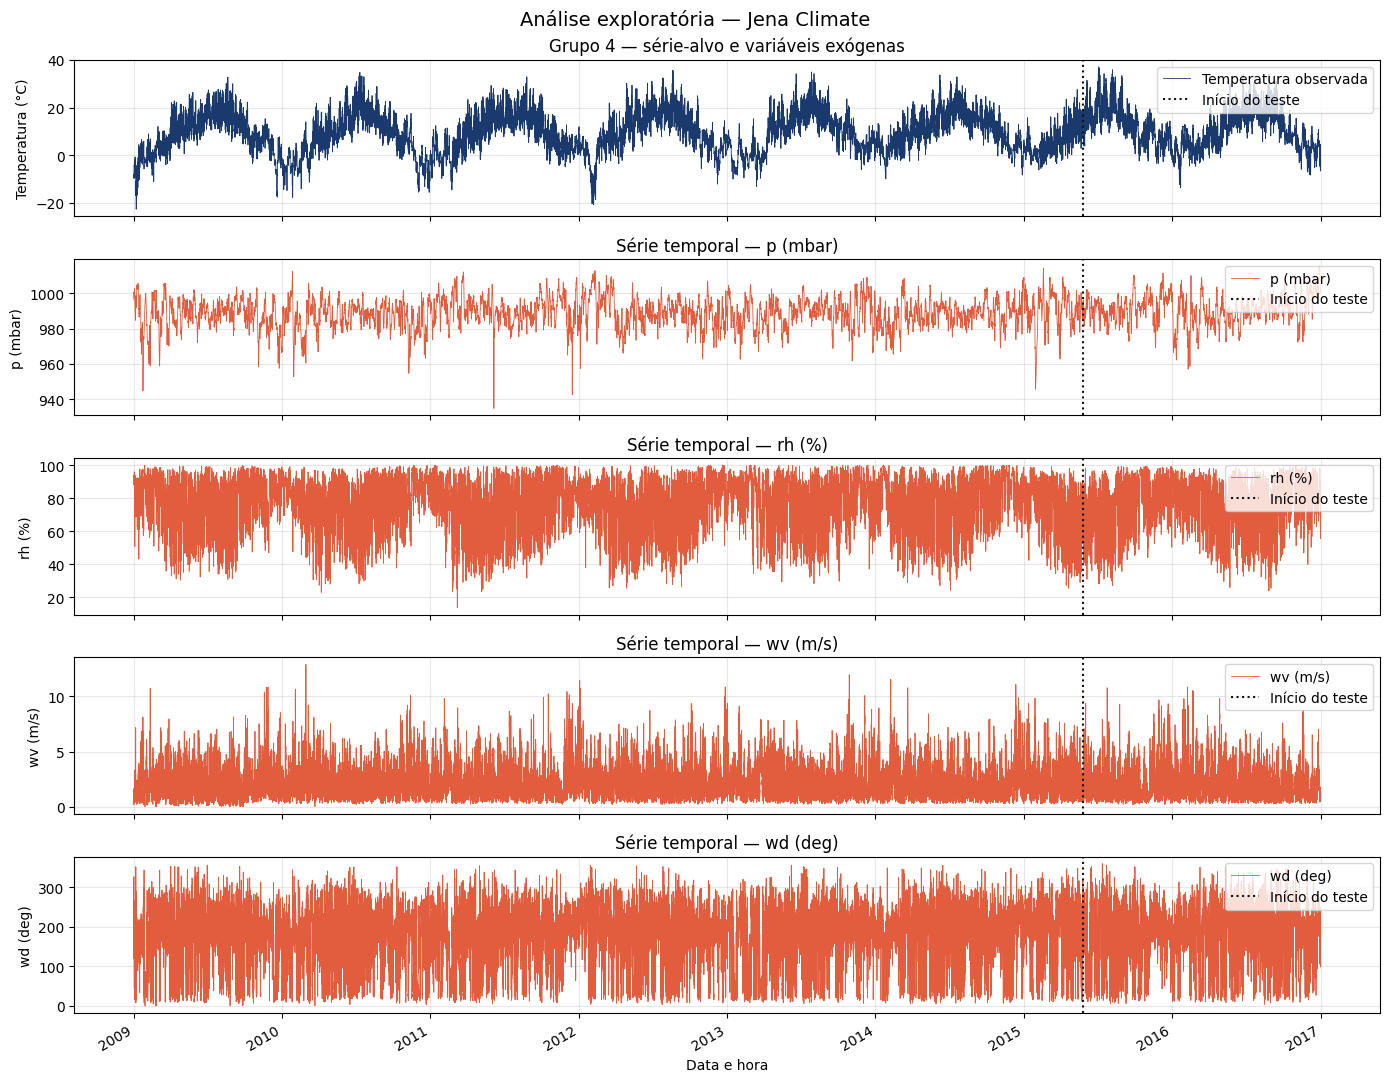

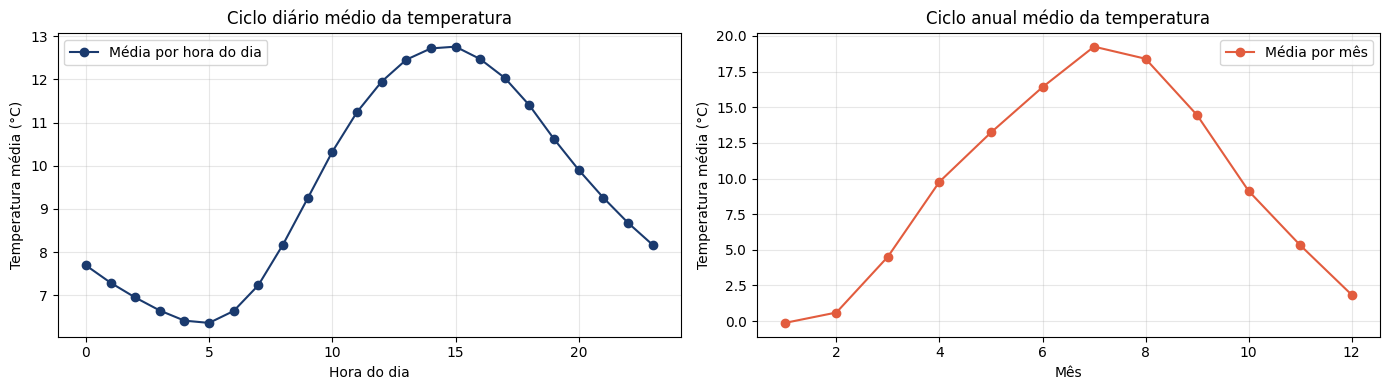

In [6]:
# T03 — análise exploratória visual
fig, axes = plt.subplots(
    len(BASE_EXOG_COLUMNS) + 1, 1, figsize=(14, 11), sharex=True, squeeze=False
)
axes = axes[:, 0]

axes[0].plot(df.index, df[TARGET_COLUMN], color="#1a3a6e", linewidth=0.6,
             label="Temperatura observada")
axes[0].axvline(INICIO_TESTE, color="#111111", linestyle=":", linewidth=1.5,
                label="Início do teste")
axes[0].set_title("Grupo 4 — série-alvo e variáveis exógenas")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

for ax, coluna in zip(axes[1:], BASE_EXOG_COLUMNS):
    ax.plot(df.index, df[coluna], linewidth=0.6, color="#e25c3e", label=coluna)
    ax.axvline(INICIO_TESTE, color="#111111", linestyle=":", linewidth=1.5,
               label="Início do teste")
    ax.set_title(f"Série temporal — {coluna}")
    ax.set_ylabel(coluna)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Data e hora")
fig.suptitle("Análise exploratória — Jena Climate", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Perfil médio por hora do dia e por mês: a sazonalidade que o m = 24 e as
# exógenas de calendário precisam capturar.
fig, (eixo_hora, eixo_mes) = plt.subplots(1, 2, figsize=(14, 4))
perfil_hora = df[TARGET_COLUMN].groupby(df.index.hour).mean()
eixo_hora.plot(perfil_hora.index, perfil_hora.to_numpy(), marker="o",
               color="#1a3a6e", label="Média por hora do dia")
eixo_hora.set_title("Ciclo diário médio da temperatura")
eixo_hora.set_xlabel("Hora do dia")
eixo_hora.set_ylabel("Temperatura média (°C)")
eixo_hora.legend()
eixo_hora.grid(alpha=0.3)

perfil_mes = df[TARGET_COLUMN].groupby(df.index.month).mean()
eixo_mes.plot(perfil_mes.index, perfil_mes.to_numpy(), marker="o",
              color="#e25c3e", label="Média por mês")
eixo_mes.set_title("Ciclo anual médio da temperatura")
eixo_mes.set_xlabel("Mês")
eixo_mes.set_ylabel("Temperatura média (°C)")
eixo_mes.legend()
eixo_mes.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

Força da sazonalidade: 0.6910
Força da tendência: 0.9579


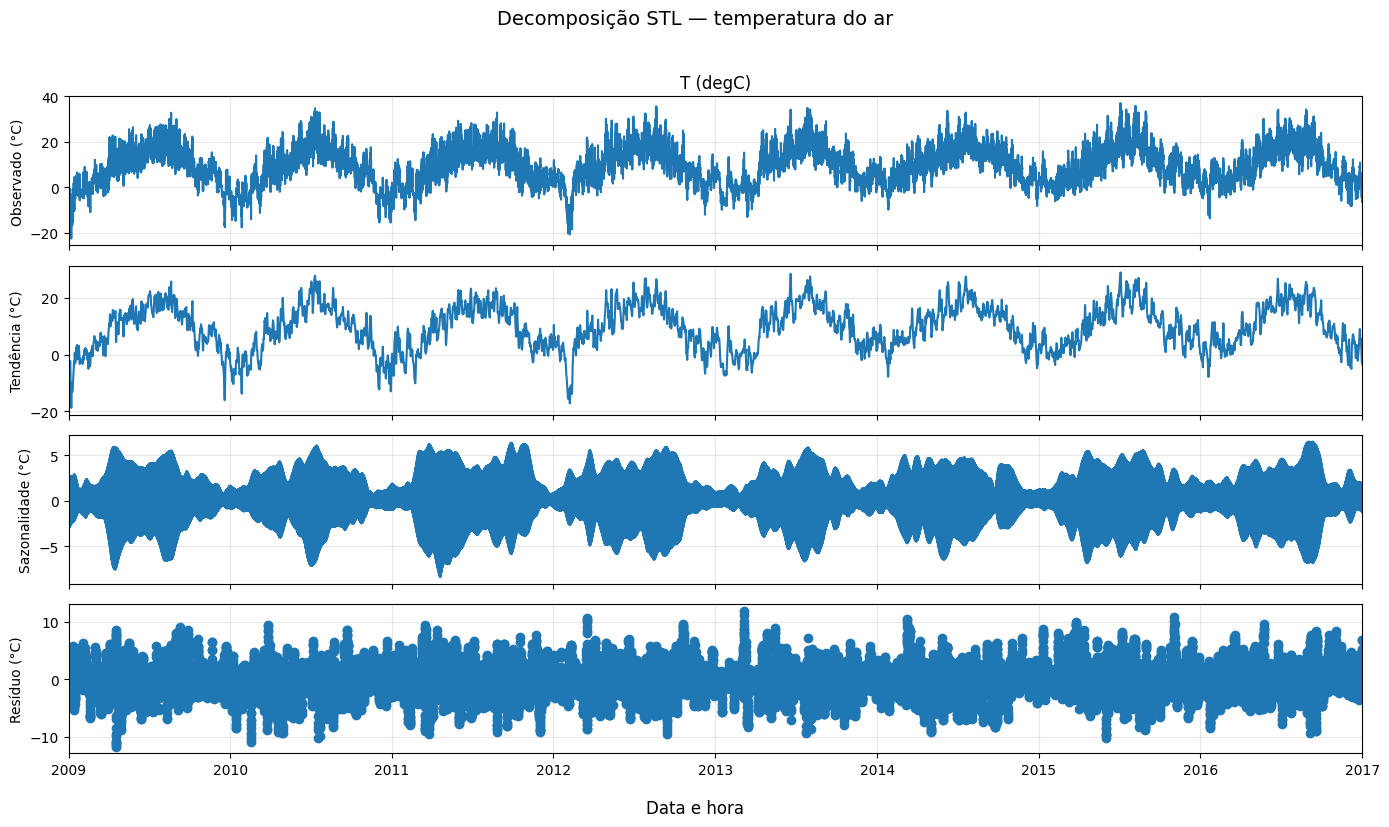

In [7]:
# Decomposição STL para a sazonalidade diária
stl_resultado = calcular_forca_sazonalidade( df[TARGET_COLUMN], periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado["decomposicao"]
print(f"Força da sazonalidade: {stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força da tendência: {stl_resultado['forca_tendencia']:.4f}")

fig = decomposicao.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Decomposição STL — temperatura do ar", fontsize=14, y=1.02)
fig.supxlabel("Data e hora")
fig.axes[0].set_ylabel("Observado (°C)")
fig.axes[1].set_ylabel("Tendência (°C)")
fig.axes[2].set_ylabel("Sazonalidade (°C)")
fig.axes[3].set_ylabel("Resíduo (°C)")
for ax in fig.axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

Média do residual: -0.036900
Desvio-padrão do residual: 1.651288


,lb_stat,lb_pvalue
1,59779.933363,0.0
2,102785.686233,0.0
3,129947.702216,0.0
4,144570.418122,0.0
5,150792.118808,0.0
6,152455.444480,0.0
7,152522.095320,0.0
8,152849.013619,0.0
9,154289.846168,0.0
10,156918.841301,0.0


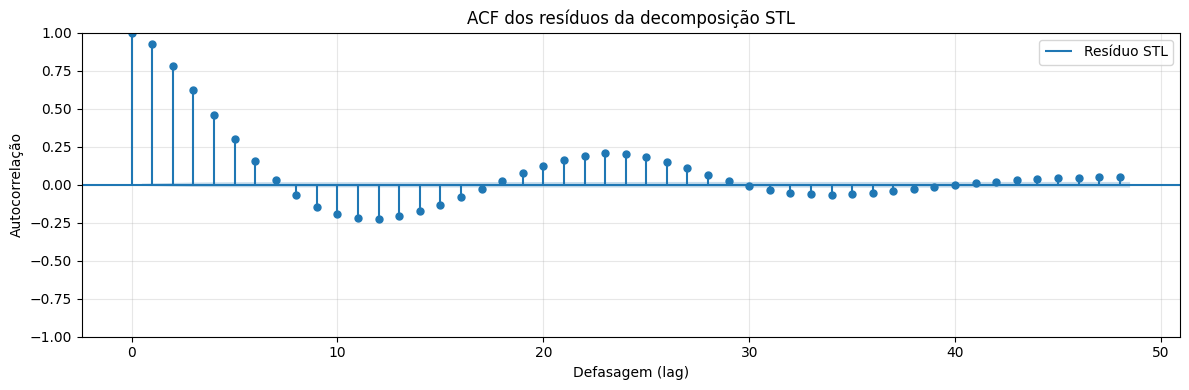

In [8]:
# Análise do componente residual
analise_residuos_stl = analisar_componente_residual(decomposicao, lags=24)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl["autocorrelacao_residual"])

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(
    analise_residuos_stl["residuo"],
    lags=48,
    ax=ax,
    title="ACF dos resíduos da decomposição STL",
)
ax.set_xlabel("Defasagem (lag)")
ax.set_ylabel("Autocorrelação")
ax.legend(["Resíduo STL"], loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Validação temporal

## T08 — Validação walk-forward

A previsão é **móvel de uma hora**: `HORIZON = 1`. A cada hora do bloco de teste o modelo prevê a hora seguinte, a observação realizada é incorporada ao estado, e a previsão avança. As origens avançam de hora em hora e cobrem todo o teste.

As exógenas entram defasadas em `EXOG_LAG = 1`, de modo que o valor usado para prever `t` é o observado em `t − 1`, que já estava disponível. A sazonalidade diária não entra como variável: ela é modelada pelo próprio SARIMAX, via `seasonal_order` com `m = 24`.

A máscara de elegibilidade reproduz os lags e janelas móveis usados na Random Forest e na MLP. Ela não alimenta o SARIMAX — serve apenas para que os três modelos sejam avaliados exatamente nos mesmos timestamps, o que é condição para comparar MAE entre eles.

O corte treino/teste vem da T01, definido sobre a série horária completa antes de qualquer defasagem, e a divisão aqui é feita por data e não por posição.


In [9]:
# T08 — features causais, máscara de elegibilidade e divisão temporal
def construir_features_temporais(
    dados, alvo, *, lags_alvo, lags_exogenas, janelas_moveis
):
    """Cria features causais; o índice da linha representa a hora prevista."""
    features = pd.DataFrame(index=dados.index)
    for lag in sorted(set(lags_alvo)):
        if lag < HORIZON:
            raise ValueError(f"Lag do alvo deve ser >= {HORIZON}: {lag}")
        features[f"target_lag_{lag}"] = dados[alvo].shift(lag)
    for coluna, lags in lags_exogenas.items():
        for lag in sorted(set(lags)):
            if lag < HORIZON:
                raise ValueError(f"Lag da exógena deve ser >= {HORIZON}: {lag}")
            features[f"{coluna}_lag_{lag}"] = dados[coluna].shift(lag)
    passado = dados[alvo].shift(HORIZON)
    for janela in sorted(set(janelas_moveis)):
        features[f"target_roll_mean_{janela}"] = passado.rolling(janela).mean()
        features[f"target_roll_std_{janela}"] = passado.rolling(janela).std()
    features["hora_sin"] = np.sin(2 * np.pi * dados.index.hour / 24)
    features["hora_cos"] = np.cos(2 * np.pi * dados.index.hour / 24)
    features["dia_semana_sin"] = np.sin(2 * np.pi * dados.index.dayofweek / 7)
    features["dia_semana_cos"] = np.cos(2 * np.pi * dados.index.dayofweek / 7)
    features["dia_ano_sin"] = np.sin(2 * np.pi * dados.index.dayofyear / 365.25)
    features["dia_ano_cos"] = np.cos(2 * np.pi * dados.index.dayofyear / 365.25)
    return pd.concat([dados[alvo].rename("target"), features], axis=1).dropna()


# Exógenas do SARIMAX: observadas em t-1 e calendário conhecido antecipadamente.
features = pd.DataFrame(index=df.index)
for coluna in EXOG_COLUMNS:
    features[f"{coluna}_lag{EXOG_LAG}"] = df[coluna].shift(EXOG_LAG)
features["hora_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
features["hora_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
features["dia_ano_sin"] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
features["dia_ano_cos"] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

# Mesma máscara de timestamps avaliada na Random Forest e na MLP.
elegibilidade = construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=[1, 2, 3, 6, 12, 24, 48, 168],
    lags_exogenas={coluna: [1, 24] for coluna in MODEL_EXOG_COLUMNS},
    janelas_moveis=[6, 24, 168],
).index

model_data = pd.concat([df[TARGET_COLUMN].rename("target"), features], axis=1).dropna()
model_data = model_data.loc[model_data.index.intersection(elegibilidade)]

train = model_data.loc[model_data.index < INICIO_TESTE]
test = model_data.loc[model_data.index >= INICIO_TESTE]
if train.empty or test.empty or train.index.max() >= test.index.min():
    raise ValueError("Divisão temporal inválida.")
y_train, y_test = train["target"], test["target"]
X_train, X_test = train.drop(columns="target"), test.drop(columns="target")

if len(y_train) <= JANELA_SELECAO + VALIDATION_HOURS:
    raise ValueError("Treino curto demais para JANELA_SELECAO + VALIDATION_HOURS.")

print(f"Treino: {len(train):,} ({len(train) / len(model_data):.1%}) | "
      f"teste: {len(test):,} ({len(test) / len(model_data):.1%})")
print(f"Corte comum: {FIM_TREINO} -> {INICIO_TESTE}")
print(f"Horizonte: {HORIZON} hora | defasagem das exógenas: {EXOG_LAG} hora")
print(f"Exógenas ({X_train.shape[1]}): {list(X_train.columns)}")
print(f"Origens de previsão no teste: {len(y_test):,} (uma por hora)")
print(f"Horas descartadas pela máscara de elegibilidade: "
      f"{len(df) - len(model_data):,}")


Treino: 55,752 (80.2%) | teste: 13,785 (19.8%)
Corte comum: 2015-05-27 14:00:00 -> 2015-05-27 15:00:00
Horizonte: 1 hora | defasagem das exógenas: 1 hora
Exógenas (9): ['p (mbar)_lag1', 'rh (%)_lag1', 'wv (m/s)_lag1', 'wd_sin_lag1', 'wd_cos_lag1', 'hora_sin', 'hora_cos', 'dia_ano_sin', 'dia_ano_cos']
Origens de previsão no teste: 13,785 (uma por hora)
Horas descartadas pela máscara de elegibilidade: 592


# 4. Modelagem SARIMAX

## T10 — SARIMAX

Seleção de `p`, `d`, `q`, `P`, `D`, `Q` e `m` por critério de informação, como manda o protocolo. O grid é o **produto cartesiano completo** dos intervalos da configuração — nenhum parâmetro é fixado de fora —, com `m = 24`, e o vencedor é o de menor `INFORMATION_CRITERION`.

**Janela de ajuste.** O grid usa um ano do treino, e não a série inteira. O custo do filtro de Kalman é aproximadamente linear no número de observações, de modo que a janela reduz o tempo por ajuste sem alterar a ordenação relativa dos candidatos, que é tudo o que o critério de informação precisa produzir. A janela termina **antes** do bloco de validação, que por isso permanece fora da amostra.

**Truncamento do otimizador.** Nenhum ajuste desta base converge dentro de 50 iterações, e o limite de iterações muda o critério de informação de forma não desprezível: no mesmo modelo, `maxiter = 50` deu BIC de −19.104 e `maxiter = 150` deu −19.303. Comparar 144 modelos todos truncados em 50 iterações mede, em parte, quão longe do ótimo cada um parou — não apenas qual ajusta melhor. Como 144 ajustes longos não cabem no orçamento, o procedimento é em dois passos: o grid barato **ordena**, e os `REFINO_TOP_K` primeiros são reajustados com `MAXITER_REFINO` para **confirmar**. A célula imprime se o refinamento mudou o vencedor; se mudou, é prova de que a ordenação barata sozinha não bastaria.

**Orçamento.** A célula cronometra um ajuste piloto e projeta o custo total **antes** de soltar o grid. Se a projeção passar de metade do teto de `ORCAMENTO_MAX_HORAS`, a execução para com uma mensagem em vez de consumir horas às cegas.

**Arrays em vez de séries.** As exógenas entram defasadas em `EXOG_LAG = 1` e são passadas como arrays. A série tem lacunas onde a temperatura não foi observada — o alvo não é imputado —, e arrays evitam que o `statsmodels` assuma um calendário regular que não existe. Em troca, os coeficientes são nomeados `x1, x2, ...`, o que a T18 traduz de volta.


Janela do grid: 2014-04-22 00:00:00 a 2015-04-29 14:00:00 (8,760 obs)
Bloco de validação: 2015-04-29 15:00:00 a 2015-05-27 14:00:00 (672 obs)
Combinações no grid: 143 | m = 24 | critério: BIC


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Ajuste piloto (2, 1, 2)x(1, 1, 1, 24): 240.6s (ok)
Orçamento previsto da triagem: 90 min (143 ajustes em 4 processos)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  2.0min
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.

Modelos ajustados: 143 de 143 | convergidos em até 50 iterações: 25


...

,order,seasonal_order,maxiter,AIC,BIC,AICc,convergiu,iteracoes,segundos,falha
0,"(2, 0, 2)","(0, 1, 1, 24)",50,-19335.363,-19222.209,-19335.301,False,50,423.9,
1,"(2, 0, 2)","(1, 1, 1, 24)",50,-19334.755,-19214.529,-19334.685,False,50,399.7,
2,"(1, 1, 1)","(1, 0, 1, 24)",50,-19300.278,-19194.155,-19300.223,False,50,70.0,
3,"(2, 1, 0)","(1, 0, 1, 24)",50,-19274.575,-19168.452,-19274.520,False,50,87.1,
4,"(2, 0, 1)","(0, 1, 1, 24)",50,-19270.885,-19164.801,-19270.830,False,50,423.6,
5,"(1, 0, 2)","(0, 1, 1, 24)",50,-19263.541,-19157.459,-19263.486,False,50,303.5,
6,"(1, 0, 2)","(1, 0, 1, 24)",50,-19269.537,-19156.339,-19269.474,False,50,69.8,
7,"(1, 0, 2)","(1, 1, 1, 24)",50,-19265.656,-19152.502,-19265.594,False,50,343.2,
8,"(0, 1, 2)","(1, 0, 1, 24)",50,-19245.305,-19139.184,-19245.250,False,50,117.5,
9,"(1, 1, 2)","(1, 0, 1, 24)",50,-19245.419,-19132.223,-19245.357,False,50,73.5,


Refinando os 5 melhores com maxiter=200: ~23 min previstos


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:  3.6min remaining:  5.4min
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed: 21.1min finishe

,order,seasonal_order,maxiter,AIC,BIC,AICc,convergiu,iteracoes,segundos,falha
0,"(2, 0, 1)","(0, 1, 1, 24)",200,-19369.348,-19263.265,-19369.293,False,200,1050.4,
1,"(2, 0, 2)","(0, 1, 1, 24)",200,-19368.308,-19255.154,-19368.246,False,200,1238.5,
2,"(2, 0, 2)","(1, 1, 1, 24)",200,-19354.809,-19234.583,-19354.739,False,200,1267.3,
3,"(1, 1, 1)","(1, 0, 1, 24)",200,-19311.504,-19205.381,-19311.449,True,139,215.2,
4,"(2, 1, 0)","(1, 0, 1, 24)",200,-19310.069,-19203.946,-19310.014,True,104,184.2,


O refinamento MUDOU o vencedor: a triagem apontava (2, 0, 2)(0, 1, 1, 24) e o reajuste longo aponta (2, 0, 1)(0, 1, 1, 24). A ordenação com maxiter=50 estava contaminada pelo truncamento do otimizador.
Hiperparâmetros congelados por BIC: order=(2, 0, 1) | seasonal_order=(0, 1, 1, 24)
  melhor da triagem por AIC : order=(2, 0, 2) seasonal_order=(0, 1, 1, 24) (AIC = -19335.4)
  melhor da triagem por BIC : order=(2, 0, 2) seasonal_order=(0, 1, 1, 24) (BIC = -19222.2)
  melhor da triagem por AICc: order=(2, 0, 2) seasonal_order=(0, 1, 1, 24) (AICc = -19335.3)


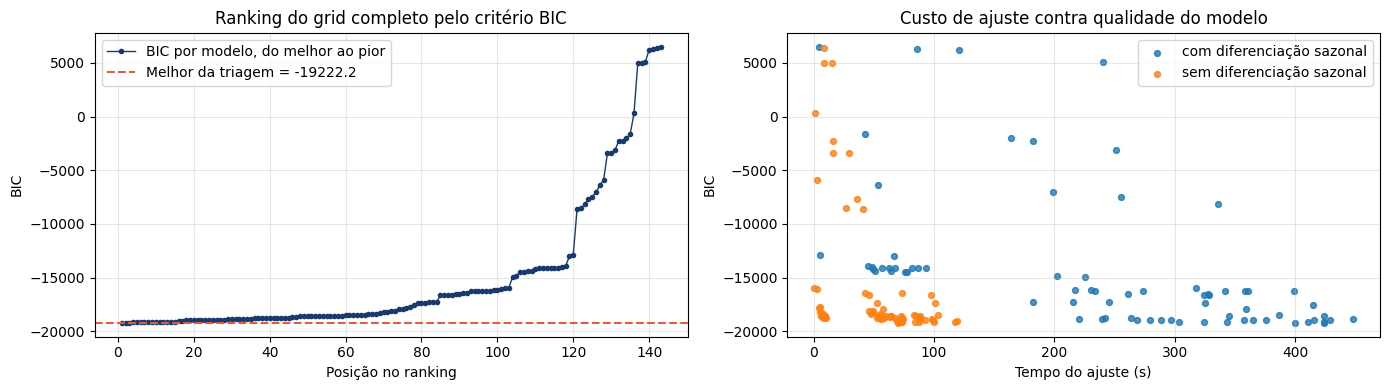

Tempo total da T10: 114.8 min (55% do teto)


In [10]:
# T10 — grid completo de (p, d, q) x (P, D, Q, m) por critério de informação
tempo_t10 = time.perf_counter()

# A janela do grid termina onde começa o bloco de validação.
y_grid = y_train.iloc[-(JANELA_SELECAO + VALIDATION_HOURS):-VALIDATION_HOURS]
X_grid = X_train.loc[y_grid.index]
y_validacao = y_train.iloc[-VALIDATION_HOURS:]
X_validacao = X_train.loc[y_validacao.index]
print(f"Janela do grid: {y_grid.index[0]} a {y_grid.index[-1]} ({len(y_grid):,} obs)")
print(f"Bloco de validação: {y_validacao.index[0]} a {y_validacao.index[-1]} "
      f"({len(y_validacao):,} obs)")

escala_y_grid, escala_x_grid = StandardScaler(), StandardScaler()
y_grid_sc = escala_y_grid.fit_transform(y_grid.to_numpy().reshape(-1, 1)).ravel()
X_grid_sc = escala_x_grid.fit_transform(X_grid.to_numpy())

# Produto cartesiano completo, sem o modelo nulo (sem termos e sem diferenciação).
combos = [
    c
    for c in itertools.product(P_RANGE, D_RANGE, Q_RANGE, PS_RANGE, DS_RANGE, QS_RANGE)
    if not (c[0] + c[2] + c[3] + c[5] == 0 and c[1] + c[4] == 0)
]
print(f"Combinações no grid: {len(combos)} | m = {M_MODELO} | "
      f"critério: {INFORMATION_CRITERION.upper()}")

COLUNA_CRITERIO = {"aic": "AIC", "bic": "BIC", "aicc": "AICc"}[INFORMATION_CRITERION]


def _ajustar(combo, maxiter):
    p, d, q, P, D, Q = combo
    registro = {"order": (p, d, q), "seasonal_order": (P, D, Q, M_MODELO),
                "maxiter": maxiter}
    inicio = time.perf_counter()
    try:
        modelo = SARIMAX(
            y_grid_sc, exog=X_grid_sc,
            order=(p, d, q), seasonal_order=(P, D, Q, M_MODELO), trend=TREND,
            enforce_stationarity=ENFORCE_STATIONARITY,
            enforce_invertibility=ENFORCE_INVERTIBILITY,
            concentrate_scale=CONCENTRATE_SCALE,
        ).fit(disp=False, maxiter=maxiter)
    except Exception as exc:
        registro.update({"AIC": np.nan, "BIC": np.nan, "AICc": np.nan,
                         "convergiu": False, "iteracoes": np.nan,
                         "segundos": round(time.perf_counter() - inicio, 1),
                         "falha": type(exc).__name__})
        return registro
    k = modelo.df_model
    registro.update({
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "AICc": modelo.aic + (2 * k * (k + 1)) / max(modelo.nobs - k - 1, 1),
        "convergiu": bool(modelo.mle_retvals.get("converged", False)),
        "iteracoes": modelo.mle_retvals.get("iterations", np.nan),
        "segundos": round(time.perf_counter() - inicio, 1),
        "falha": "",
    })
    return registro


# ---------- 1. triagem: grid completo com maxiter curto ----------
# Ajuste piloto de um modelo pesado (com diferenciação sazonal), que é o que
# domina o custo; usar um combo leve subestimaria o orçamento.
combo_piloto = (2, 1, 2, 1, 1, 1) if (2, 1, 2, 1, 1, 1) in combos else combos[-1]
inicio_piloto = time.perf_counter()
piloto = _ajustar(combo_piloto, MAXITER)
segundos_piloto = time.perf_counter() - inicio_piloto
# Modelos sem diferenciação sazonal custam cerca de um quarto do piloto.
fracao_pesada = sum(1 for c in combos if c[4] == 1) / len(combos)
segundos_medios = segundos_piloto * (fracao_pesada + 0.25 * (1 - fracao_pesada))
horas_previstas = segundos_medios * len(combos) / max(N_JOBS_GRID, 1) / 3600
print(f"Ajuste piloto {piloto['order']}x{piloto['seasonal_order']}: "
      f"{segundos_piloto:.1f}s ({'ok' if not piloto['falha'] else piloto['falha']})")
print(f"Orçamento previsto da triagem: {horas_previstas * 60:.0f} min "
      f"({len(combos)} ajustes em {N_JOBS_GRID} processos)")
if horas_previstas > ORCAMENTO_MAX_HORAS / 2:
    raise RuntimeError(
        f"A triagem sozinha consumiria {horas_previstas:.1f} h, mais da metade do "
        f"teto de {ORCAMENTO_MAX_HORAS} h. Reduza JANELA_SELECAO ou MAXITER."
    )

triagem = Parallel(n_jobs=N_JOBS_GRID, verbose=5)(
    delayed(_ajustar)(combo, MAXITER) for combo in combos
)
df_grid = (
    pd.DataFrame(triagem)
    .dropna(subset=[COLUNA_CRITERIO])
    .sort_values(COLUNA_CRITERIO)
    .reset_index(drop=True)
)
print(f"Modelos ajustados: {len(df_grid)} de {len(combos)} | "
      f"convergidos em até {MAXITER} iterações: {int(df_grid['convergiu'].sum())}")
display(df_grid.head(10).round(3))

ORDER_TRIAGEM = tuple(df_grid.loc[0, "order"])
SEASONAL_ORDER_TRIAGEM = tuple(df_grid.loc[0, "seasonal_order"])

# ---------- 2. refinamento dos melhores com maxiter longo ----------
if REFINO_TOP_K > 0:
    a_refinar = [
        (linha["order"][0], linha["order"][1], linha["order"][2],
         linha["seasonal_order"][0], linha["seasonal_order"][1],
         linha["seasonal_order"][2])
        for _, linha in df_grid.head(REFINO_TOP_K).iterrows()
    ]
    horas_refino = (
        df_grid.head(REFINO_TOP_K)["segundos"].sum()
        * (MAXITER_REFINO / MAXITER) / max(N_JOBS_GRID, 1) / 3600
    )
    print(f"Refinando os {len(a_refinar)} melhores com maxiter={MAXITER_REFINO}: "
          f"~{horas_refino * 60:.0f} min previstos")
    refino = Parallel(n_jobs=min(N_JOBS_GRID, len(a_refinar)), verbose=5)(
        delayed(_ajustar)(combo, MAXITER_REFINO) for combo in a_refinar
    )
    df_refino = (
        pd.DataFrame(refino)
        .dropna(subset=[COLUNA_CRITERIO])
        .sort_values(COLUNA_CRITERIO)
        .reset_index(drop=True)
    )
    display(df_refino.round(3))
    ORDER = tuple(df_refino.loc[0, "order"])
    SEASONAL_ORDER = tuple(df_refino.loc[0, "seasonal_order"])
    if (ORDER, SEASONAL_ORDER) != (ORDER_TRIAGEM, SEASONAL_ORDER_TRIAGEM):
        print(f"O refinamento MUDOU o vencedor: a triagem apontava "
              f"{ORDER_TRIAGEM}{SEASONAL_ORDER_TRIAGEM} e o reajuste longo aponta "
              f"{ORDER}{SEASONAL_ORDER}. A ordenação com maxiter={MAXITER} "
              f"estava contaminada pelo truncamento do otimizador.")
    else:
        print("O refinamento confirmou o vencedor da triagem.")
    df_refino.to_csv(SAIDA / "refino_sarimax_grupo4.csv", index=False)
else:
    ORDER, SEASONAL_ORDER = ORDER_TRIAGEM, SEASONAL_ORDER_TRIAGEM

print(f"Hiperparâmetros congelados por {COLUNA_CRITERIO}: "
      f"order={ORDER} | seasonal_order={SEASONAL_ORDER}")

# Se AIC, BIC e AICc apontam modelos diferentes, a escolha depende do critério
# e não dos dados. Isso precisa ficar visível, não escondido no vencedor.
for criterio in ("AIC", "BIC", "AICc"):
    linha = df_grid.sort_values(criterio).iloc[0]
    print(f"  melhor da triagem por {criterio:4s}: order={tuple(linha['order'])} "
          f"seasonal_order={tuple(linha['seasonal_order'])} "
          f"({criterio} = {linha[criterio]:.1f})")

fig, (eixo_rank, eixo_custo) = plt.subplots(1, 2, figsize=(14, 4))
valores = df_grid[COLUNA_CRITERIO].to_numpy()
eixo_rank.plot(range(1, len(valores) + 1), valores, marker="o", markersize=3,
               linewidth=1.0, color="#1a3a6e",
               label=f"{COLUNA_CRITERIO} por modelo, do melhor ao pior")
eixo_rank.axhline(valores[0], color="#e25c3e", linestyle="--",
                  label=f"Melhor da triagem = {valores[0]:.1f}")
eixo_rank.set_title(f"Ranking do grid completo pelo critério {COLUNA_CRITERIO}")
eixo_rank.set_xlabel("Posição no ranking")
eixo_rank.set_ylabel(COLUNA_CRITERIO)
eixo_rank.legend()
eixo_rank.grid(alpha=0.3)

custo = df_grid.assign(
    sazonal=np.where([s[1] == 1 for s in df_grid["seasonal_order"]],
                     "com diferenciação sazonal", "sem diferenciação sazonal")
)
for rotulo, grupo in custo.groupby("sazonal"):
    eixo_custo.scatter(grupo["segundos"], grupo[COLUNA_CRITERIO], s=18,
                       alpha=0.8, label=rotulo)
eixo_custo.set_title("Custo de ajuste contra qualidade do modelo")
eixo_custo.set_xlabel("Tempo do ajuste (s)")
eixo_custo.set_ylabel(COLUNA_CRITERIO)
eixo_custo.legend()
eixo_custo.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tempo_t10 = time.perf_counter() - tempo_t10
print(f"Tempo total da T10: {tempo_t10 / 60:.1f} min "
      f"({tempo_t10 / 3600 / ORCAMENTO_MAX_HORAS:.0%} do teto)")
df_grid.to_csv(SAIDA / "grid_sarimax_grupo4.csv", index=False)


### T10b — Conferência do modelo escolhido no bloco de validação

O critério de informação mede a qualidade do ajuste dentro da amostra, com penalização pelo número de parâmetros. Ele **não** mede erro de previsão de uma hora à frente, que é a tarefa avaliada na T16.

Esta célula não escolhe nada: os hiperparâmetros já estão congelados. Ela ajusta o vencedor no histórico anterior ao bloco de validação e percorre as `VALIDATION_HOURS` horas seguintes em previsão móvel de uma hora, informando qual MAE esperar.

O ajuste usa **a mesma janela `JANELA_REFIT`** que a T16 usará em cada reajuste. Isso tem duas consequências desejáveis: o MAE de validação passa a ser comparável com o MAE de teste, porque os dois vêm de modelos estimados sobre a mesma quantidade de histórico; e o tempo cronometrado aqui vira uma **régua exata** do custo de um reajuste da T16, e não uma extrapolação.

O procedimento usa `append(..., refit=False)`, que incorpora as observações já realizadas ao filtro de Kalman sem reestimar os parâmetros. As previsões obtidas assim são idênticas, valor a valor, às de um laço que prevê uma hora e reencaixa a observação — foi verificado — mas custam uma passagem do filtro em vez de centenas.

Ao final, os objetos de resultados são descartados explicitamente com `del` e `gc.collect()`. Eles carregam as matrizes de covariância de estado descritas na configuração, e mantê-los vivos enquanto a T16 roda foi o que esgotou a memória da máquina na primeira tentativa.


Ajuste da conferência: 17,520 obs (2013-04-22 00:00:00 a 2015-04-29 14:00:00)
Janela de reajuste: 17520 h | k_states = 50
Uma matriz de covariância de estado: 0.36 GB


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Ajuste concluído em 6.9 min | convergiu: False
MAE de validação de SARIMAX(2, 0, 1)(0, 1, 1, 24): 0.4546 °C
RMSE de validação: 0.6435 °C | viés médio: +0.0245 °C


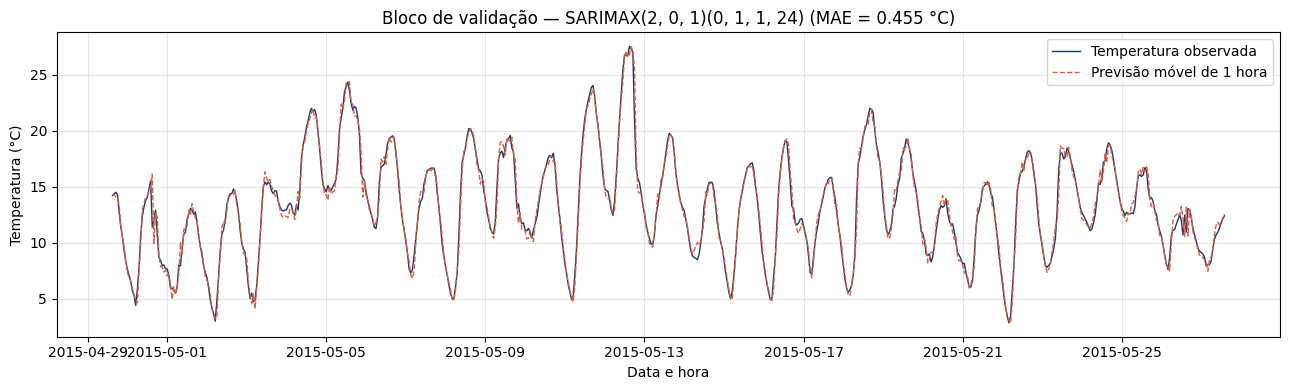

Tempo total da conferência: 7.0 min
Gasto acumulado: 2.03 h de 3.5 h | restam 0.94 h úteis
A T16 quer 10 reajustes e o orçamento comporta 8; ela usará o menor dos dois.


In [11]:
# T10b — conferência do modelo congelado no bloco de validação
tempo_t10b = time.perf_counter()

# Mesma janela dos reajustes da T16, para que o MAE e o tempo sejam comparáveis.
y_ajuste = y_train.loc[y_train.index < y_validacao.index[0]]
if JANELA_REFIT is not None:
    y_ajuste = y_ajuste.iloc[-JANELA_REFIT:]
X_ajuste = X_train.loc[y_ajuste.index]

escala_y_val, escala_x_val = StandardScaler(), StandardScaler()
y_ajuste_sc = escala_y_val.fit_transform(y_ajuste.to_numpy().reshape(-1, 1)).ravel()
X_ajuste_sc = escala_x_val.fit_transform(X_ajuste.to_numpy())
X_validacao_sc = escala_x_val.transform(X_validacao.to_numpy())
y_validacao_sc = escala_y_val.transform(y_validacao.to_numpy().reshape(-1, 1)).ravel()

# Projeção de memória antes de ajustar: k_states depende de (p, d, q) e de
# (P, D, Q, m), e as covariâncias de estado têm forma (k_states, k_states, nobs).
modelo_validacao = SARIMAX(
    y_ajuste_sc, exog=X_ajuste_sc, order=ORDER, seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=ENFORCE_STATIONARITY,
    enforce_invertibility=ENFORCE_INVERTIBILITY,
    concentrate_scale=CONCENTRATE_SCALE,
)
K_STATES = modelo_validacao.k_states
gb_por_matriz = K_STATES ** 2 * (len(y_ajuste_sc) + VALIDATION_HOURS) * 8 / 1e9
print(f"Ajuste da conferência: {len(y_ajuste):,} obs "
      f"({y_ajuste.index[0]} a {y_ajuste.index[-1]})")
print(f"Janela de reajuste: "
      f"{'histórico completo' if JANELA_REFIT is None else f'{JANELA_REFIT} h'} | "
      f"k_states = {K_STATES}")
print(f"Uma matriz de covariância de estado: {gb_por_matriz:.2f} GB")

inicio_ajuste = time.perf_counter()
ajuste_validacao = modelo_validacao.fit(disp=False, maxiter=MAXITER)
SEGUNDOS_POR_REFIT = time.perf_counter() - inicio_ajuste
print(f"Ajuste concluído em {SEGUNDOS_POR_REFIT / 60:.1f} min | "
      f"convergiu: {ajuste_validacao.mle_retvals.get('converged', False)}")

n_ajuste = len(y_ajuste_sc)
estado_validacao = ajuste_validacao.append(
    y_validacao_sc, exog=X_validacao_sc, refit=False
)
previsao_sc = np.asarray(
    estado_validacao.get_prediction(
        start=n_ajuste, end=n_ajuste + len(y_validacao_sc) - 1, dynamic=False
    ).predicted_mean
)
previsao_validacao = escala_y_val.inverse_transform(
    previsao_sc.reshape(-1, 1)
).ravel()

# Os objetos de resultados guardam as covariâncias de estado dimensionadas
# acima. A T16 vai alocar as suas, então estes precisam sair da memória agora.
del estado_validacao, ajuste_validacao, modelo_validacao
gc.collect()

df_validacao = pd.DataFrame({
    "data": y_validacao.index,
    "real": y_validacao.to_numpy(),
    "previsto": previsao_validacao,
})
df_validacao["residuo"] = df_validacao["real"] - df_validacao["previsto"]
MAE_VALIDACAO = df_validacao["residuo"].abs().mean()
RMSE_VALIDACAO = np.sqrt(np.mean(np.square(df_validacao["residuo"])))
print(f"MAE de validação de SARIMAX{ORDER}{SEASONAL_ORDER}: {MAE_VALIDACAO:.4f} °C")
print(f"RMSE de validação: {RMSE_VALIDACAO:.4f} °C | "
      f"viés médio: {df_validacao['residuo'].mean():+.4f} °C")

fig, eixo = plt.subplots(figsize=(13, 4))
eixo.plot(df_validacao["data"], df_validacao["real"], color="#1a3a6e",
          linewidth=1.0, label="Temperatura observada")
eixo.plot(df_validacao["data"], df_validacao["previsto"], color="#e25c3e",
          linewidth=1.0, linestyle="--", label="Previsão móvel de 1 hora")
eixo.set_title(f"Bloco de validação — SARIMAX{ORDER}{SEASONAL_ORDER} "
               f"(MAE = {MAE_VALIDACAO:.3f} °C)")
eixo.set_xlabel("Data e hora")
eixo.set_ylabel("Temperatura (°C)")
eixo.legend()
eixo.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Projeção do custo da T16. Com JANELA_REFIT os reajustes do teste têm
# exatamente o mesmo tamanho do ajuste acima, então isto não é extrapolação.
tempo_t10b = time.perf_counter() - tempo_t10b
n_refits_alvo = int(np.ceil(len(y_test) / REFIT_ALVO_HORAS))
tempo_disponivel = (
    ORCAMENTO_MAX_HORAS * 3600 * (1 - MARGEM_ORCAMENTO) - tempo_t10 - tempo_t10b
)
n_refits_possiveis = int(tempo_disponivel // SEGUNDOS_POR_REFIT)
print(f"Tempo total da conferência: {tempo_t10b / 60:.1f} min")
print(f"Gasto acumulado: {(tempo_t10 + tempo_t10b) / 3600:.2f} h de "
      f"{ORCAMENTO_MAX_HORAS} h | restam {tempo_disponivel / 3600:.2f} h úteis")
print(f"A T16 quer {n_refits_alvo} reajustes e o orçamento comporta "
      f"{n_refits_possiveis}; ela usará o menor dos dois.")
df_validacao.to_csv(SAIDA / "validacao_sarimax_grupo4.csv", index=False)


# 5. Avaliação

## T16 — Comparação por MAE

A avaliação percorre **todas as horas** do bloco de teste em previsão móvel de uma hora: para cada hora `t`, o modelo prevê `t` usando exógenas de `t − 1` e todas as observações até `t − 1`.

O teste é dividido em blocos. No início de cada bloco os parâmetros são reestimados sobre a **janela `JANELA_REFIT` mais recente** do histórico disponível até ali; dentro do bloco, as observações realizadas entram no filtro de Kalman com `append(..., refit=False)`, que atualiza o estado sem reestimar nada. Foi verificado nesta base que as previsões obtidas por bloco são idênticas, valor a valor, às de um laço hora a hora — a diferença está só no custo.

A janela é o que torna o custo de cada reajuste constante em vez de crescente, e é o que mantém as matrizes de covariância de estado dentro da memória da máquina. Note a distinção: a janela limita o histórico usado para **estimar os parâmetros**, e não a informação usada para **prever**. Toda observação realizada até a hora anterior continua entrando no estado do filtro, via `append`.

Reestimar a cada hora seriam mais de treze mil ajustes, o que é inviável; não reestimar nunca ignoraria qualquer mudança ao longo de quase dois anos de teste. O número de reajustes é, por isso, **derivado do orçamento**: a célula parte do alvo de um reajuste a cada `REFIT_ALVO_HORAS` e o reduz se o tempo restante até `ORCAMENTO_MAX_HORAS` não comportar todos, usando o custo de reajuste já cronometrado na T10b. É uma decisão de custo, declarada e visível, e não uma escolha estatística.

Ao fim de cada bloco os objetos de resultados são descartados com `del` e `gc.collect()`, de modo que a memória ocupada não se acumule de um bloco para o seguinte.

O MAE está em graus Celsius e usa apenas previsões fora da amostra. Como o horizonte é de um passo, o MAE por passo perde sentido; no lugar dele a célula reporta o MAE por mês e por hora do dia, que mostram em que condições o modelo erra mais.


Orçamento: 3.5 h | já gastos 2.03 h | restam 0.94 h (com margem de 15%)
Custo de um reajuste: 6.9 min -> cabem 8 | alvo era 10
O orçamento reduziu os reajustes de 10 para 8: os parâmetros ficarão fixos por 1724 h de teste em vez de 1440 h.
Horas no teste: 13,785 | blocos: 8 (1724 h cada)
Janela de estimação por bloco: 17,520 h | k_states = 50


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Bloco 1/8 | 2015-05-27 15:00:00 a 2015-08-07 10:00:00 | estimado em 17,520 obs | MAE 0.5048 °C | ajuste 5.8 min


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Bloco 2/8 | 2015-08-07 11:00:00 a 2015-10-18 06:00:00 | estimado em 17,520 obs | MAE 0.4931 °C | ajuste 6.4 min


...

Bloco 7/8 | 2016-07-31 15:00:00 a 2016-10-11 10:00:00 | estimado em 17,520 obs | MAE 0.4263 °C | ajuste 5.7 min


/Users/sofia.santana/Documents/pipeline_ml/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Bloco 8/8 | 2016-10-11 11:00:00 a 2017-01-01 00:00:00 | estimado em 17,520 obs | MAE 0.3260 °C | ajuste 5.8 min

Previsões de uma hora: 13,785 | reajustes: 8
Tempo da avaliação: 47.9 min
Tempo total do pipeline: 2.83 h de um teto de 3.5 h


,base,modelo,horizonte_horas,MAE,RMSE,ME_vies,MaxAE,n_previsoes,refits,horas_por_refit,janela_refit_h,MAE_validacao,tempo_t10_min,tempo_avaliacao_min
0,clima,"SARIMAX (2, 0, 1)(0, 1, 1, 24)",1,0.4273,0.6101,0.0004,6.9764,13785,8,1724,17520,0.4546,114.8454,47.8833


MAE de validação: 0.4546 °C | MAE de teste: 0.4273 °C. Os dois vêm de modelos estimados sobre a mesma janela, então a diferença entre eles mede mudança de período, e não diferença de quantidade de histórico.
Cobertura do IC 95%: 94.7% (esperado cerca de 95%)


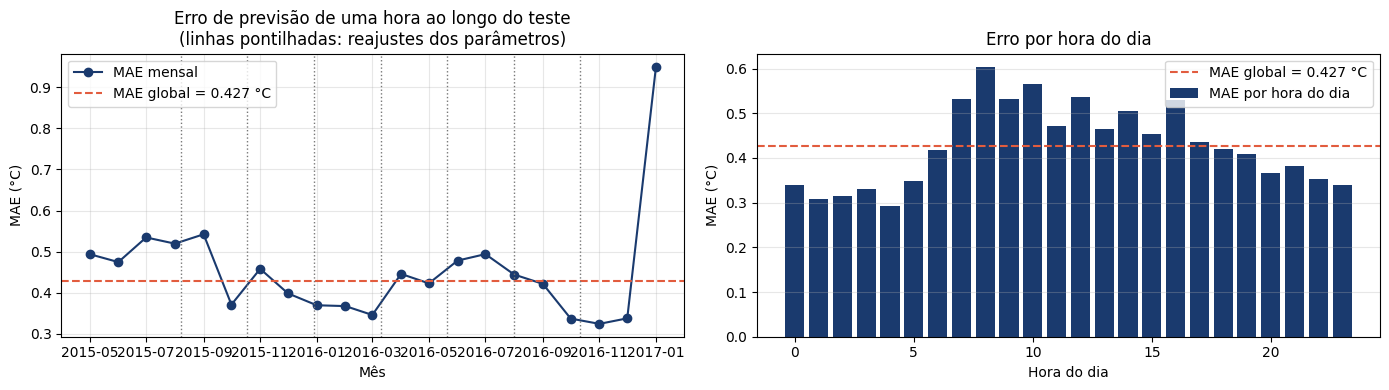

In [12]:
# T16 — previsão móvel de uma hora no teste, com reajuste em janela deslizante
tempo_avaliacao = time.perf_counter()

# ---------- número de reajustes derivado do orçamento restante ----------
tempo_gasto = tempo_t10 + tempo_t10b
tempo_restante = ORCAMENTO_MAX_HORAS * 3600 * (1 - MARGEM_ORCAMENTO) - tempo_gasto
if tempo_restante <= SEGUNDOS_POR_REFIT:
    raise RuntimeError(
        f"Restam {tempo_restante / 60:.0f} min do orçamento e um único reajuste custa "
        f"{SEGUNDOS_POR_REFIT / 60:.0f} min. Aumente ORCAMENTO_MAX_HORAS ou reduza "
        f"JANELA_REFIT e rode a T10b de novo."
    )
n_refits_possiveis = int(tempo_restante // SEGUNDOS_POR_REFIT)
n_refits_alvo = int(np.ceil(len(y_test) / REFIT_ALVO_HORAS))
N_REFITS = max(1, min(n_refits_alvo, n_refits_possiveis))
REFIT_EVERY_HORAS = int(np.ceil(len(y_test) / N_REFITS))

print(f"Orçamento: {ORCAMENTO_MAX_HORAS} h | já gastos {tempo_gasto / 3600:.2f} h | "
      f"restam {tempo_restante / 3600:.2f} h (com margem de {MARGEM_ORCAMENTO:.0%})")
print(f"Custo de um reajuste: {SEGUNDOS_POR_REFIT / 60:.1f} min "
      f"-> cabem {n_refits_possiveis} | alvo era {n_refits_alvo}")
if N_REFITS < n_refits_alvo:
    print(f"O orçamento reduziu os reajustes de {n_refits_alvo} para {N_REFITS}: "
          f"os parâmetros ficarão fixos por {REFIT_EVERY_HORAS} h de teste "
          f"em vez de {REFIT_ALVO_HORAS} h.")

blocos = [
    (inicio, min(inicio + REFIT_EVERY_HORAS, len(y_test)))
    for inicio in range(0, len(y_test), REFIT_EVERY_HORAS)
]
print(f"Horas no teste: {len(y_test):,} | blocos: {len(blocos)} "
      f"({REFIT_EVERY_HORAS} h cada)")
print(f"Janela de estimação por bloco: "
      f"{'histórico completo' if JANELA_REFIT is None else f'{JANELA_REFIT:,} h'} | "
      f"k_states = {K_STATES}")

registros = []
refits = 0
for numero, (inicio, fim) in enumerate(blocos, start=1):
    # Histórico disponível na primeira hora do bloco: treino + teste já ocorrido.
    # A janela limita o que é usado para ESTIMAR; o que é usado para PREVER
    # continua sendo tudo até a hora anterior, por meio do append abaixo.
    y_hist = pd.concat([y_train, y_test.iloc[:inicio]])
    if JANELA_REFIT is not None:
        y_hist = y_hist.iloc[-JANELA_REFIT:]
    X_hist = pd.concat([X_train, X_test.iloc[:inicio]]).loc[y_hist.index]

    sc_y, sc_x = StandardScaler(), StandardScaler()
    y_hist_sc = sc_y.fit_transform(y_hist.to_numpy().reshape(-1, 1)).ravel()
    X_hist_sc = sc_x.fit_transform(X_hist.to_numpy())

    inicio_fit = time.perf_counter()
    ajuste = SARIMAX(
        y_hist_sc, exog=X_hist_sc, order=ORDER, seasonal_order=SEASONAL_ORDER,
        trend=TREND,
        enforce_stationarity=ENFORCE_STATIONARITY,
        enforce_invertibility=ENFORCE_INVERTIBILITY,
        concentrate_scale=CONCENTRATE_SCALE,
    ).fit(disp=False, maxiter=MAXITER)
    segundos_fit = time.perf_counter() - inicio_fit
    refits += 1

    y_bloco = y_test.iloc[inicio:fim]
    X_bloco = X_test.iloc[inicio:fim]
    y_bloco_sc = sc_y.transform(y_bloco.to_numpy().reshape(-1, 1)).ravel()
    X_bloco_sc = sc_x.transform(X_bloco.to_numpy())

    # Cada previsão usa as observações até a hora anterior, sem reestimar.
    estado = ajuste.append(y_bloco_sc, exog=X_bloco_sc, refit=False)
    n_hist = len(y_hist_sc)
    predicao = estado.get_prediction(
        start=n_hist, end=n_hist + len(y_bloco_sc) - 1, dynamic=False
    )
    previsao = sc_y.inverse_transform(
        np.asarray(predicao.predicted_mean).reshape(-1, 1)
    ).ravel()
    intervalo = sc_y.inverse_transform(np.asarray(predicao.conf_int(alpha=0.05)))

    registros.append(pd.DataFrame({
        "modelo": "SARIMAX",
        "bloco": numero,
        "data": y_bloco.index,
        "real": y_bloco.to_numpy(),
        "previsto": previsao,
        "ic_inf": intervalo[:, 0],
        "ic_sup": intervalo[:, 1],
    }))
    print(f"Bloco {numero}/{len(blocos)} | {y_bloco.index[0]} a {y_bloco.index[-1]} "
          f"| estimado em {len(y_hist):,} obs "
          f"| MAE {np.abs(y_bloco.to_numpy() - previsao).mean():.4f} °C "
          f"| ajuste {segundos_fit / 60:.1f} min")

    # Os coeficientes do último bloco alimentam a T18. São vetores pequenos;
    # guardá-los permite descartar o objeto de resultados, que é o que pesa.
    coeficientes_finais = pd.Series(ajuste.params, index=ajuste.param_names)
    pvalores_finais = pd.Series(ajuste.pvalues, index=ajuste.param_names)
    ajuste_convergiu = bool(ajuste.mle_retvals.get("converged", False))

    # Libera as covariâncias de estado antes do próximo bloco alocar as suas.
    del estado, ajuste, predicao, y_hist, X_hist, y_hist_sc, X_hist_sc
    gc.collect()

wf = pd.concat(registros, ignore_index=True)
wf["residuo"] = wf["real"] - wf["previsto"]
tempo_avaliacao = time.perf_counter() - tempo_avaliacao
erros = wf["residuo"].to_numpy()

metricas = pd.DataFrame([{
    "base": "clima",
    "modelo": f"SARIMAX {ORDER}{SEASONAL_ORDER}",
    "horizonte_horas": HORIZON,
    "MAE": np.abs(erros).mean(),
    "RMSE": np.sqrt(np.mean(np.square(erros))),
    "ME_vies": erros.mean(),
    "MaxAE": np.abs(erros).max(),
    "n_previsoes": len(wf),
    "refits": refits,
    "horas_por_refit": REFIT_EVERY_HORAS,
    "janela_refit_h": JANELA_REFIT if JANELA_REFIT else len(y_train),
    "MAE_validacao": MAE_VALIDACAO,
    "tempo_t10_min": tempo_t10 / 60,
    "tempo_avaliacao_min": tempo_avaliacao / 60,
}])
print(f"\nPrevisões de uma hora: {len(wf):,} | reajustes: {refits}")
print(f"Tempo da avaliação: {tempo_avaliacao / 60:.1f} min")
print(f"Tempo total do pipeline: "
      f"{(tempo_gasto + tempo_avaliacao) / 3600:.2f} h de um teto de "
      f"{ORCAMENTO_MAX_HORAS} h")
display(metricas.round(4))

print(f"MAE de validação: {MAE_VALIDACAO:.4f} °C | "
      f"MAE de teste: {np.abs(erros).mean():.4f} °C. Os dois vêm de modelos "
      f"estimados sobre a mesma janela, então a diferença entre eles mede "
      f"mudança de período, e não diferença de quantidade de histórico.")

cobertura = ((wf["real"] >= wf["ic_inf"]) & (wf["real"] <= wf["ic_sup"])).mean()
print(f"Cobertura do IC 95%: {100 * cobertura:.1f}% (esperado cerca de 95%)")

mae_por_mes = wf.groupby(wf["data"].dt.to_period("M"))["residuo"].apply(
    lambda s: s.abs().mean()
)
mae_por_hora = wf.groupby(wf["data"].dt.hour)["residuo"].apply(lambda s: s.abs().mean())

fig, (eixo_mes, eixo_hora) = plt.subplots(1, 2, figsize=(14, 4))
eixo_mes.plot(mae_por_mes.index.to_timestamp(), mae_por_mes.to_numpy(),
              marker="o", color="#1a3a6e", label="MAE mensal")
eixo_mes.axhline(metricas.loc[0, "MAE"], color="#e25c3e", linestyle="--",
                 label=f"MAE global = {metricas.loc[0, 'MAE']:.3f} °C")
for _, (_, fim_bloco) in enumerate(blocos[:-1]):
    eixo_mes.axvline(wf["data"].iloc[fim_bloco - 1], color="#777777",
                     linestyle=":", linewidth=1)
eixo_mes.set_title("Erro de previsão de uma hora ao longo do teste\n"
                   "(linhas pontilhadas: reajustes dos parâmetros)")
eixo_mes.set_xlabel("Mês")
eixo_mes.set_ylabel("MAE (°C)")
eixo_mes.legend()
eixo_mes.grid(alpha=0.3)

eixo_hora.bar(mae_por_hora.index, mae_por_hora.to_numpy(), color="#1a3a6e",
              label="MAE por hora do dia")
eixo_hora.axhline(metricas.loc[0, "MAE"], color="#e25c3e", linestyle="--",
                  label=f"MAE global = {metricas.loc[0, 'MAE']:.3f} °C")
eixo_hora.set_title("Erro por hora do dia")
eixo_hora.set_xlabel("Hora do dia")
eixo_hora.set_ylabel("MAE (°C)")
eixo_hora.legend()
eixo_hora.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

wf.to_csv(SAIDA / "previsoes_sarimax_grupo4.csv", index=False)
metricas.to_csv(SAIDA / "metricas_sarimax_grupo4.csv", index=False)
mae_por_mes.rename("MAE").to_csv(SAIDA / "mae_por_mes_sarimax_grupo4.csv")


## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

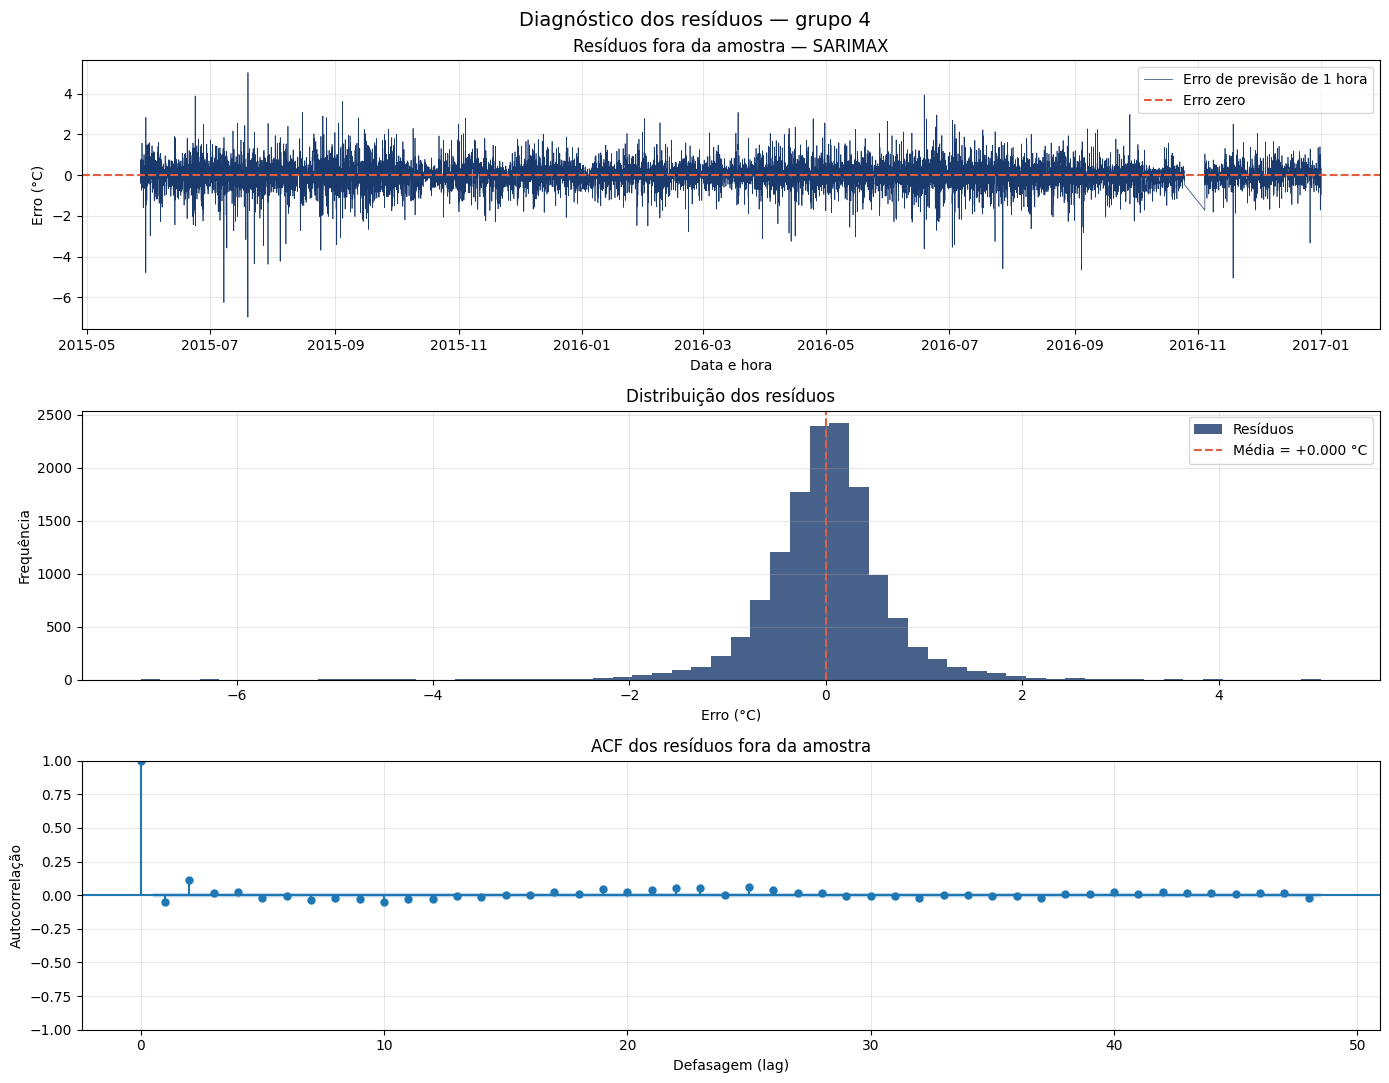

,lb_stat,lb_pvalue
1,34.881433,3.504066e-09
2,203.523313,6.389606e-45
3,205.826954,2.322902e-44
4,215.604070,1.655038e-45
5,222.089344,5.301212e-46
6,223.153419,2.211832e-45
7,244.445447,4.212600e-49
8,249.600708,2.093495e-49
9,262.200721,2.639164e-51
10,300.902328,1.002037e-58


Viés médio: +0.0004 °C | desvio-padrão: 0.6102 °C
O resíduo é real menos previsto: ME < 0 indica superestimação média, ME > 0 indica subestimação média.
Ljung-Box: há autocorrelação residual (p < 0,05). Com horizonte de um passo os resíduos deveriam ser ruído branco, então a rejeição indica estrutura temporal que a ordem escolhida não capturou. Vale ler junto com a ACF: autocorrelação em lags múltiplos de 24 aponta sazonalidade diária residual.


In [13]:
# T17 — diagnóstico dos resíduos fora da amostra
residuos_teste = wf.set_index("data")["residuo"]
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
axes[0].plot(residuos_teste.index, residuos_teste.to_numpy(), color="#1a3a6e",
             linewidth=0.5, label="Erro de previsão de 1 hora")
axes[0].axhline(0, color="#e25c3e", linestyle="--", label="Erro zero")
axes[0].set_title("Resíduos fora da amostra — SARIMAX")
axes[0].set_xlabel("Data e hora")
axes[0].set_ylabel("Erro (°C)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuos_teste.to_numpy(), bins=60, alpha=0.8, color="#1a3a6e",
             label="Resíduos")
axes[1].axvline(residuos_teste.mean(), color="#e25c3e", linestyle="--",
                label=f"Média = {residuos_teste.mean():+.3f} °C")
axes[1].set_title("Distribuição dos resíduos")
axes[1].set_xlabel("Erro (°C)")
axes[1].set_ylabel("Frequência")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plot_acf(residuos_teste, lags=48, ax=axes[2],
         title="ACF dos resíduos fora da amostra")
axes[2].set_xlabel("Defasagem (lag)")
axes[2].set_ylabel("Autocorrelação")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Diagnóstico dos resíduos — grupo 4", fontsize=14)
plt.tight_layout()
plt.show()

analise_residuos_teste = analisar_componente_residual(
    type("Decomposicao", (), {"resid": residuos_teste})(), lags=24
)
ljung_box = analise_residuos_teste["autocorrelacao_residual"]
display(ljung_box)
print(f"Viés médio: {residuos_teste.mean():+.4f} °C | "
      f"desvio-padrão: {residuos_teste.std():.4f} °C")
print("O resíduo é real menos previsto: ME < 0 indica superestimação média, "
      "ME > 0 indica subestimação média.")
if (ljung_box["lb_pvalue"] < 0.05).any():
    print("Ljung-Box: há autocorrelação residual (p < 0,05). Com horizonte de um "
          "passo os resíduos deveriam ser ruído branco, então a rejeição indica "
          "estrutura temporal que a ordem escolhida não capturou. Vale ler junto "
          "com a ACF: autocorrelação em lags múltiplos de 24 aponta sazonalidade "
          "diária residual.")
else:
    print("Ljung-Box: não houve rejeição de ruído branco nos lags avaliados, "
          "o que é o esperado para previsão de um passo bem especificada.")
ljung_box.to_csv(SAIDA / "ljung_box_sarimax_grupo4.csv")


## T18 — Importância das features

Cálculo e interpretação da importância das features: permutation importance para modelos de tabela e coeficientes para o SARIMAX.

,variavel,coeficiente,p_valor,importancia_absoluta,signif_5pct
8,dia_ano_cos,-0.728002,0.000000,0.728002,True
7,dia_ano_sin,-0.353273,0.000007,0.353273,True
0,p (mbar)_lag1,-0.126621,0.000000,0.126621,True
1,rh (%)_lag1,0.086310,0.000000,0.086310,True
2,wv (m/s)_lag1,-0.003311,0.000273,0.003311,True
3,wd_sin_lag1,0.001441,0.008146,0.001441,True
4,wd_cos_lag1,-0.000133,0.816951,0.000133,False
5,hora_sin,0.000000,0.000000,0.000000,True
6,hora_cos,-0.000000,0.122223,0.000000,False


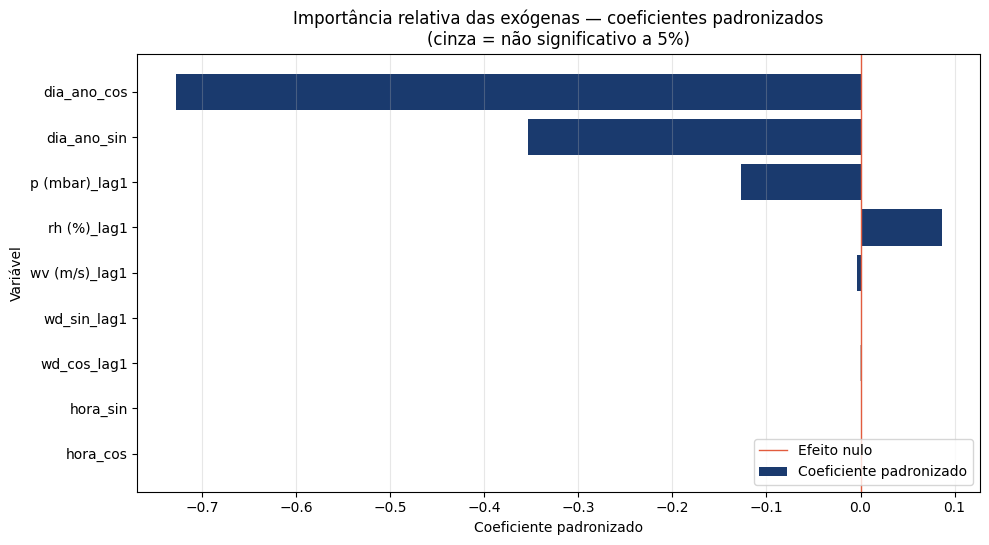

Como as exógenas foram padronizadas, o coeficiente é o efeito em desvios-padrão do alvo por desvio-padrão da variável, e os valores são comparáveis entre si. Os termos autorregressivos não aparecem nesta tabela: com horizonte de uma hora, a maior parte da previsão vem deles, e não das exógenas.
Atenção: o último reajuste não convergiu dentro do limite de iterações. Os p-valores vêm da matriz de informação avaliada no ponto em que o otimizador parou, e devem ser lidos como indicativos, não como teste formal.


In [14]:
# T18 — coeficientes das exógenas padronizadas
# Os coeficientes vêm do último reajuste da T16, guardado antes de o objeto de
# resultados ser descartado. O ajuste usa arrays para tolerar as lacunas do
# calendário, então o statsmodels nomeia as exógenas como x1, x2, ... A tabela
# abaixo traduz de volta para os nomes das colunas.
nomes_statsmodels = [f"x{i}" for i in range(1, X_train.shape[1] + 1)]

coeficientes = pd.DataFrame({
    "variavel": X_train.columns,
    "coeficiente": [coeficientes_finais.get(nome, np.nan) for nome in nomes_statsmodels],
    "p_valor": [pvalores_finais.get(nome, np.nan) for nome in nomes_statsmodels],
})
coeficientes["importancia_absoluta"] = coeficientes["coeficiente"].abs()
coeficientes["signif_5pct"] = coeficientes["p_valor"] < 0.05
coeficientes = coeficientes.sort_values("importancia_absoluta", ascending=False)
display(coeficientes.round(6))

fig, ax = plt.subplots(figsize=(10, 0.45 * len(coeficientes) + 1.5))
cores = ["#1a3a6e" if s else "#bbbbbb" for s in coeficientes["signif_5pct"]]
ax.barh(coeficientes["variavel"], coeficientes["coeficiente"], color=cores,
        label="Coeficiente padronizado")
ax.axvline(0, color="#e25c3e", lw=1, label="Efeito nulo")
ax.set_title("Importância relativa das exógenas — coeficientes padronizados\n"
             "(cinza = não significativo a 5%)")
ax.set_xlabel("Coeficiente padronizado")
ax.set_ylabel("Variável")
ax.legend(loc="lower right")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Como as exógenas foram padronizadas, o coeficiente é o efeito em desvios-"
      "padrão do alvo por desvio-padrão da variável, e os valores são comparáveis "
      "entre si. Os termos autorregressivos não aparecem nesta tabela: com "
      "horizonte de uma hora, a maior parte da previsão vem deles, e não das "
      "exógenas.")
if not ajuste_convergiu:
    print("Atenção: o último reajuste não convergiu dentro do limite de iterações. "
          "Os p-valores vêm da matriz de informação avaliada no ponto em que o "
          "otimizador parou, e devem ser lidos como indicativos, não como teste "
          "formal.")
coeficientes.to_csv(SAIDA / "coeficientes_sarimax_grupo4.csv", index=False)


Matriz T06 (clima): 69,537 linhas x 30 features | máscara idêntica à da T08: sim
Exógenas da T06 idênticas às usadas no SARIMAX (T08): ok
Último bloco: 2016-10-11 11:00:00 a 2017-01-01 00:00:00 (1,717 h) | estimado em 17,520 obs
MAE do bloco recalculado: 0.3260 °C | MAE do bloco na T16: 0.3260 °C | diferença: 0.00e+00
Avaliação de um conjunto de features: 4 s | 18 avaliações previstas: ~1 min


,grupo,colunas,MAE_base,MAE_permutado,importancia_MAE,desvio_importancia,aumento_pct
0,dia do ano,"dia_ano_sin, dia_ano_cos",0.326,5.3971,5.0711,0.1611,1555.6804
1,p (mbar) [t-1],p (mbar)_lag_1,0.326,2.0151,1.6891,0.0378,518.1757
2,rh (%) [t-1],rh (%)_lag_1,0.326,0.8150,0.4890,0.0165,150.0164
3,wv (m/s) [t-1],wv (m/s)_lag_1,0.326,0.3281,0.0021,0.0015,0.6423
4,hora do dia,"hora_sin, hora_cos",0.326,0.3260,0.0000,0.0000,0.0000
5,direção do vento [t-1],"wd_sin_lag_1, wd_cos_lag_1",0.326,0.3253,-0.0007,0.0005,-0.2155


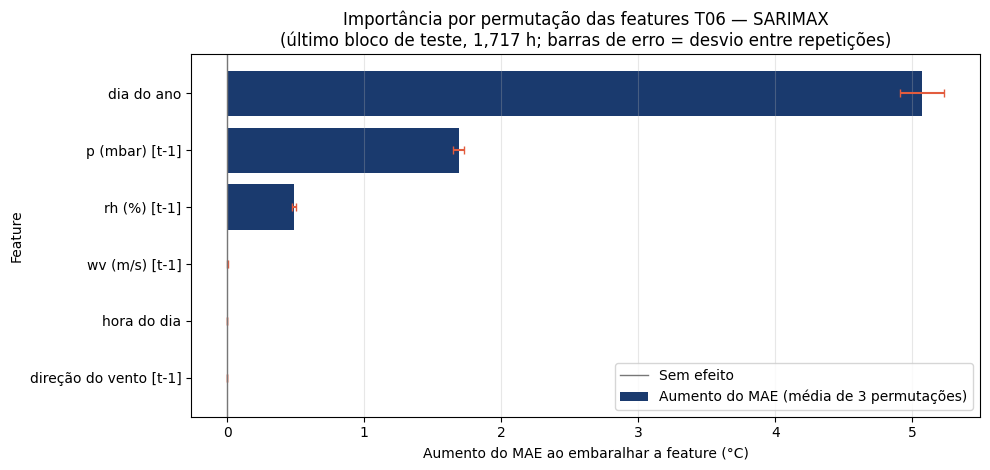

Embaralhar uma feature dentro do bloco, com os parâmetros congelados, mede quanto a previsão de uma hora piora sem a informação dela; valores próximos de zero indicam que o modelo quase não depende da feature. A medida cobre só as exógenas: os termos AR/MA, que carregam a maior parte da previsão a uma hora, não são permutados. Sem reajuste, features correlacionadas podem dividir ou superestimar a importância, e o resultado descreve o último bloco, não o teste inteiro.
Tempo da T19: 1.2 min


In [16]:
# T19 — importância por permutação das features temporais (módulo T06) no SARIMAX
import features_temporais as ft   # alias: não sobrescreve a função local da T08

tempo_t19 = time.perf_counter()
N_REPETICOES = 3

# ---------- 1. as funções da T06 reproduzem o que a T08 já usou ----------
# (a) mesma máscara de elegibilidade, agora vinda de preparar_features_base;
# (b) mesmas exógenas do SARIMAX, agora vindas de construir_features_temporais.
matriz_t06 = ft.preparar_features_base(
    df, "clima", TARGET_COLUMN, FREQUENCY, remover_incompletos=True
)
mascara_igual = matriz_t06.index.equals(elegibilidade)
print(f"Matriz T06 (clima): {matriz_t06.shape[0]:,} linhas x "
      f"{matriz_t06.shape[1] - 1} features | máscara idêntica à da T08: "
      f"{'sim' if mascara_igual else 'NÃO'}")

COLUNAS_T06 = (
    [f"{c}_lag_{EXOG_LAG}" for c in EXOG_COLUMNS]
    + ["hora_sin", "hora_cos", "dia_ano_sin", "dia_ano_cos"]
)
X_t06 = ft.construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=[EXOG_LAG],
    lags_exogenas={c: [EXOG_LAG] for c in EXOG_COLUMNS},
    janelas_moveis=[],
    calendario=("hora", "dia_ano"),
    horizonte=HORIZON,
    frequencia=FREQUENCY,
)[COLUNAS_T06]
X_modelo = pd.concat([X_train, X_test])
X_t06 = X_t06.loc[X_modelo.index]
if not np.allclose(X_t06.to_numpy(), X_modelo.to_numpy()):
    raise ValueError("As features da T06 diferem das exógenas usadas pelo SARIMAX.")
print("Exógenas da T06 idênticas às usadas no SARIMAX (T08): ok")

# Variáveis que são o mesmo sinal em seno/cosseno entram e saem juntas.
GRUPOS = {
    "p (mbar) [t-1]": [f"p (mbar)_lag_{EXOG_LAG}"],
    "rh (%) [t-1]": [f"rh (%)_lag_{EXOG_LAG}"],
    "wv (m/s) [t-1]": [f"wv (m/s)_lag_{EXOG_LAG}"],
    "direção do vento [t-1]": [f"wd_sin_lag_{EXOG_LAG}", f"wd_cos_lag_{EXOG_LAG}"],
    "hora do dia": ["hora_sin", "hora_cos"],
    "dia do ano": ["dia_ano_sin", "dia_ano_cos"],
}

# ---------- 2. refiltra o último bloco da T16 com os parâmetros congelados ----------
# Nada é reestimado: os parâmetros são os de coeficientes_finais (último reajuste
# da T16). O método é o mesmo da T16, append(..., refit=False): é ele que garante
# previsões idênticas às já reportadas. Cada avaliação refiltra a janela inteira
# mais o bloco, então o custo é o de um append da T16 por permutação.
inicio_u, fim_u = blocos[-1]
y_hist_u = pd.concat([y_train, y_test.iloc[:inicio_u]])
if JANELA_REFIT is not None:
    y_hist_u = y_hist_u.iloc[-JANELA_REFIT:]
X_hist_u = X_t06.loc[y_hist_u.index]
y_bloco_u = y_test.iloc[inicio_u:fim_u]
X_bloco_u = X_t06.loc[y_bloco_u.index]

sc_y_u, sc_x_u = StandardScaler(), StandardScaler()
y_hist_sc_u = sc_y_u.fit_transform(y_hist_u.to_numpy().reshape(-1, 1)).ravel()
X_hist_sc_u = sc_x_u.fit_transform(X_hist_u.to_numpy())
y_bloco_sc_u = sc_y_u.transform(y_bloco_u.to_numpy().reshape(-1, 1)).ravel()

modelo_u = SARIMAX(
    y_hist_sc_u, exog=X_hist_sc_u, order=ORDER, seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=ENFORCE_STATIONARITY,
    enforce_invertibility=ENFORCE_INVERTIBILITY,
    concentrate_scale=CONCENTRATE_SCALE,
)
estado_u = modelo_u.filter(coeficientes_finais.to_numpy())


def _mae_bloco(X_df):
    """MAE (°C) de uma hora à frente no último bloco, dadas as exógenas X_df."""
    ext = estado_u.append(y_bloco_sc_u, exog=sc_x_u.transform(X_df.to_numpy()),
                          refit=False)
    prev_sc = np.asarray(ext.get_prediction(
        start=len(y_hist_sc_u), end=len(y_hist_sc_u) + len(y_bloco_sc_u) - 1,
        dynamic=False
    ).predicted_mean)
    del ext
    prev = sc_y_u.inverse_transform(prev_sc.reshape(-1, 1)).ravel()
    return float(np.abs(y_bloco_u.to_numpy() - prev).mean())


inicio_base = time.perf_counter()
mae_base_u = _mae_bloco(X_bloco_u)
segundos_avaliacao = time.perf_counter() - inicio_base
mae_ref_u = float(wf.loc[wf["bloco"] == len(blocos), "residuo"].abs().mean())
print(f"Último bloco: {y_bloco_u.index[0]} a {y_bloco_u.index[-1]} "
      f"({len(y_bloco_u):,} h) | estimado em {len(y_hist_u):,} obs")
print(f"MAE do bloco recalculado: {mae_base_u:.4f} °C | MAE do bloco na T16: "
      f"{mae_ref_u:.4f} °C | diferença: {abs(mae_base_u - mae_ref_u):.2e}")
if abs(mae_base_u - mae_ref_u) > 1e-4:
    print("Atenção: o MAE recalculado não bate com o da T16; a importância "
          "abaixo não deve ser lida antes de se entender a diferença.")

# ---------- 3. permutação ----------
print(f"Avaliação de um conjunto de features: {segundos_avaliacao:.0f} s | "
      f"{len(GRUPOS) * N_REPETICOES} avaliações previstas: "
      f"~{len(GRUPOS) * N_REPETICOES * segundos_avaliacao / 60:.0f} min")
rng_u = np.random.default_rng(SEED)
linhas = []
for nome, colunas in GRUPOS.items():
    maes = []
    for _ in range(N_REPETICOES):
        permutacao = rng_u.permutation(len(X_bloco_u))
        X_perm = X_bloco_u.copy()
        X_perm[colunas] = X_bloco_u[colunas].to_numpy()[permutacao]
        maes.append(_mae_bloco(X_perm))
    linhas.append({
        "grupo": nome,
        "colunas": ", ".join(colunas),
        "MAE_base": mae_base_u,
        "MAE_permutado": np.mean(maes),
        "importancia_MAE": np.mean(maes) - mae_base_u,
        "desvio_importancia": np.std(maes, ddof=1),
        "aumento_pct": 100 * (np.mean(maes) / mae_base_u - 1),
    })
importancia_perm = (
    pd.DataFrame(linhas).sort_values("importancia_MAE", ascending=False)
    .reset_index(drop=True)
)
display(importancia_perm.round(4))

fig, ax = plt.subplots(figsize=(10, 0.55 * len(importancia_perm) + 1.5))
ax.barh(importancia_perm["grupo"], importancia_perm["importancia_MAE"],
        xerr=importancia_perm["desvio_importancia"], color="#1a3a6e",
        ecolor="#e25c3e", capsize=3,
        label=f"Aumento do MAE (média de {N_REPETICOES} permutações)")
ax.axvline(0, color="#777777", lw=1, label="Sem efeito")
ax.set_title("Importância por permutação das features T06 — SARIMAX\n"
             f"(último bloco de teste, {len(y_bloco_u):,} h; barras de erro = "
             "desvio entre repetições)")
ax.set_xlabel("Aumento do MAE ao embaralhar a feature (°C)")
ax.set_ylabel("Feature")
ax.legend(loc="lower right")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Embaralhar uma feature dentro do bloco, com os parâmetros congelados, "
      "mede quanto a previsão de uma hora piora sem a informação dela; valores "
      "próximos de zero indicam que o modelo quase não depende da feature. A "
      "medida cobre só as exógenas: os termos AR/MA, que carregam a maior parte "
      "da previsão a uma hora, não são permutados. Sem reajuste, features "
      "correlacionadas podem dividir ou superestimar a importância, e o "
      "resultado descreve o último bloco, não o teste inteiro.")

del estado_u, modelo_u, y_hist_sc_u, X_hist_sc_u
gc.collect()
importancia_perm.to_csv(SAIDA / "importancia_permutacao_sarimax_grupo4.csv", index=False)
print(f"Tempo da T19: {(time.perf_counter() - tempo_t19) / 60:.1f} min")